# EDA Inicial — Dataset de Propiedades en Venta, Mérida, Yucatán

Análisis exploratorio del dataset recolectado manualmente en la Fase 1 
del proyecto. 60 propiedades en venta de 6 colonias de Mérida, Yucatán.
Fuente: Inmuebles24, mayo–junio 2026.

## 1. Configuración del entorno
Importación de librerías y configuración de parámetros globales de visualización.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Todo listo")

Matplotlib is building the font cache; this may take a moment.


Todo listo


## 2. Carga de datos

In [2]:
df = pd.read_csv('/Users/edson/Documents/GitHub/dataset-inmuebles-merida/data/propiedades.csv')
df.head()

,fecha_registro,url,url_archivo,operación,tipo_inmueble,colonia,precio,m2_construccion,m2_terreno,recamaras,banos,estacionamientos,antigüedad,es_preventa,notas
0,2026-05-29,https://www.inmuebles24.com/propiedades/clasif...,NaN,venta,casa,altabrisa,2390000,100,160,2,1,2.0,20.0,no,Casa en fraccionamiento Vista Alegre Norte. Ca...
1,2026-05-29,https://www.inmuebles24.com/propiedades/clasif...,NaN,venta,departamento,altabrisa,2285000,46,46,1,1,1.0,NaN,si,"Preventa, múltiples unidades, precio cabecera ..."
2,2026-05-29,https://www.inmuebles24.com/propiedades/clasif...,NaN,venta,departamento,altabrisa,6200000,160,160,2,3,2.0,NaN,no,"Country Towers Altabrisa, anuncio no especific..."
3,2026-05-29,https://www.inmuebles24.com/propiedades/clasif...,NaN,venta,casa,altabrisa,7500000,292,326,4,3,2.0,10.0,no,"Sin cuota de mantenimiento, piscina con cascad..."
4,2026-05-29,https://www.inmuebles24.com/propiedades/clasif...,NaN,venta,casa,altabrisa,27000000,800,890,4,4,2.0,6.0,no,"Casa en condominio, piscina con baño completo,..."


## 3. Inspección inicial
Vista general del dataset: dimensiones, tipos de datos, primeras y últimas filas.

In [3]:
df.shape

(60, 15)

In [4]:
df.dtypes

fecha_registro          str
url                     str
url_archivo         float64
operación               str
tipo_inmueble           str
colonia                 str
precio                int64
m2_construccion       int64
m2_terreno            int64
recamaras             int64
banos                 int64
estacionamientos    float64
antigüedad          float64
es_preventa             str
notas                   str
dtype: object

In [5]:
df.tail()

,fecha_registro,url,url_archivo,operación,tipo_inmueble,colonia,precio,m2_construccion,m2_terreno,recamaras,banos,estacionamientos,antigüedad,es_preventa,notas
55,2026-06-07,https://www.inmuebles24.com/propiedades/clasif...,NaN,venta,casa,yucatan country club,38500000,900,1208,4,7,4.0,7.0,no,"piscina (8x3.5m), bodega, despacho con baño co..."
56,2026-06-07,https://www.inmuebles24.com/propiedades/clasif...,NaN,venta,casa,yucatan country club,41000000,730,752,4,4,3.0,NaN,no,"frente al campo de golf, family room, estudio ..."
57,2026-06-07,https://www.inmuebles24.com/propiedades/clasif...,NaN,venta,departamento,yucatan country club,6200000,171,60,3,3,2.0,8.0,no,desarrollo Privada Serena (51 casas y 88 depar...
58,2026-06-07,https://www.inmuebles24.com/propiedades/clasif...,NaN,venta,casa,yucatan country club,12665000,496,525,3,3,2.0,7.0,no,"piscina con baño y asoleadero, jardín con casc..."
59,2026-06-07,https://www.inmuebles24.com/propiedades/clasif...,NaN,venta,casa,yucatan country club,12900000,410,466,3,4,2.0,NaN,no,piscina con veneciano y baño exterior (entrada...


## 4. Calidad de datos
Análisis de valores faltantes por columna y evaluación de su impacto en el análisis.

In [6]:
faltantes = df.isnull().sum()
porcentaje = (faltantes / len(df) * 100).round(1)
pd.DataFrame({'faltantes': faltantes, 'porcentaje': porcentaje})

,faltantes,porcentaje
fecha_registro,0,0.0
url,0,0.0
url_archivo,60,100.0
operación,0,0.0
tipo_inmueble,0,0.0
colonia,0,0.0
precio,0,0.0
m2_construccion,0,0.0
m2_terreno,0,0.0
recamaras,0,0.0


### Observaciones
- Las variables clave para el modelo (precio, m2_construccion, m2_terreno, recamaras, banos) 
  están completas al 100%.
- antigüedad tiene 65% de valores faltantes y tendrá uso limitado en fases posteriores.
- url_archivo está vacía por diseño: Inmuebles24 bloquea el archivado en Wayback Machine.
- estacionamientos tiene un solo valor faltante (1.7%), manejable.

## 5. Estadística descriptiva
Resumen estadístico de las variables numéricas: precio, m2, recámaras, baños, estacionamientos, antigüedad.

In [8]:
df[['precio', 'm2_construccion', 'm2_terreno', 'recamaras', 'banos', 'estacionamientos', 'antigüedad']].describe().round(2)

,precio,m2_construccion,m2_terreno,recamaras,banos,estacionamientos,antigüedad
count,60.00,60.00,60.00,60.00,60.00,59.00,21.00
mean,8163095.10,298.08,420.68,2.85,2.78,2.17,8.76
std,8761005.24,355.16,858.90,1.01,1.39,1.12,9.19
min,1790000.00,42.00,42.00,1.00,1.00,1.00,1.00
25%,2900000.00,126.00,126.50,2.00,2.00,1.00,3.00
50%,4942500.00,175.50,198.00,3.00,2.50,2.00,6.00
75%,8687500.00,356.25,423.75,3.25,3.00,2.00,10.00
max,41000000.00,2502.00,6531.00,5.00,7.00,6.00,40.00


### Observaciones
- precio y m2 presentan sesgo a la derecha (media >> mediana), 
  con outliers en el extremo superior. El modelo probablemente 
  requerirá transformación logarítmica del precio.
- recamaras es la variable más estable, centrada en 3.
- antigüedad solo cubre 21 de 60 registros; su uso en el modelo 
  será limitado.
- Se detectan posibles outliers en m2_construccion (max 2,502), 
  m2_terreno (max 6,531) y banos (max 7). Se investigarán en la 
  Sección 10.

## 6. Distribuciones univariadas
Distribución individual de cada variable numérica clave.

### 6.1 Precio

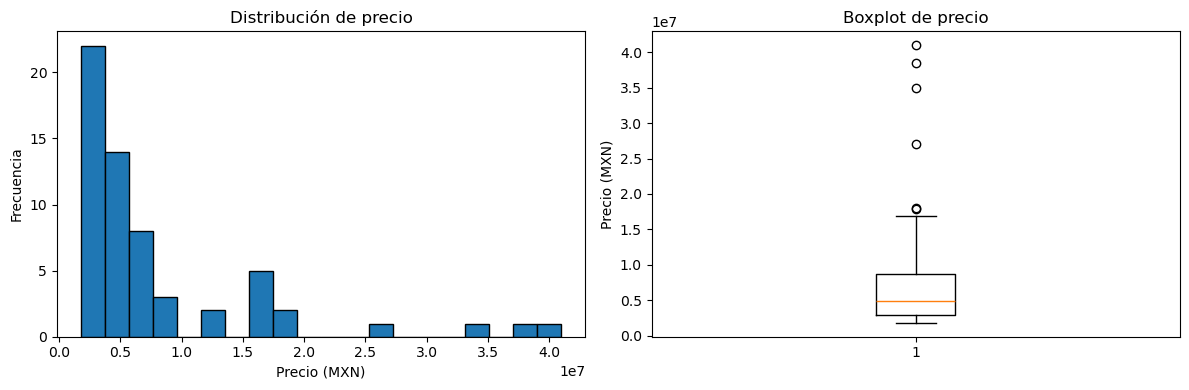

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['precio'], bins=20, edgecolor='black')
axes[0].set_title('Distribución de precio')
axes[0].set_xlabel('Precio (MXN)')
axes[0].set_ylabel('Frecuencia')

axes[1].boxplot(df['precio'])
axes[1].set_title('Boxplot de precio')
axes[1].set_ylabel('Precio (MXN)')

plt.tight_layout()
plt.show()

**Observación 6.1:** El precio muestra sesgo positivo marcado. La mayoría 
de propiedades se concentra entre \$2M y \$5M MXN, con una cola de 
propiedades de lujo que llegan hasta $41M. Se detectan 5 outliers en el 
extremo superior. Se confirma la necesidad de transformación logarítmica 
para el modelo.

### 6.2 Precio por m² de construcción

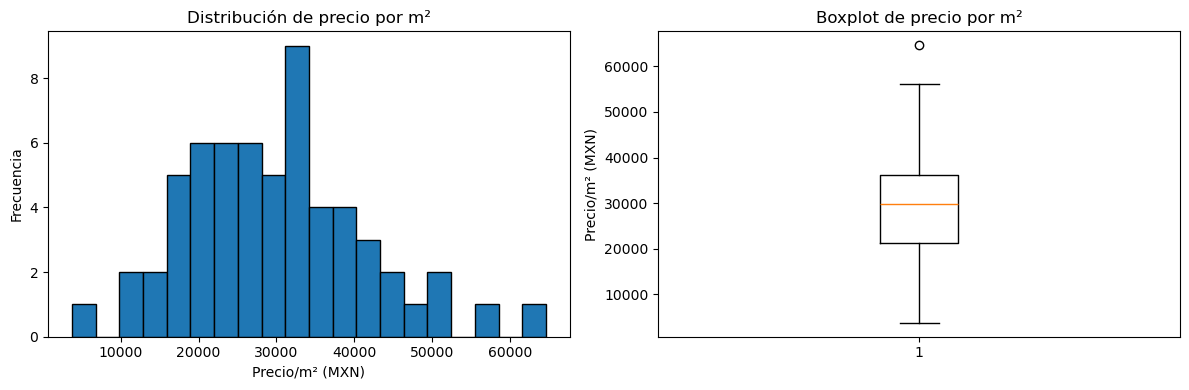

In [10]:
df['precio_m2'] = df['precio'] / df['m2_construccion']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['precio_m2'], bins=20, edgecolor='black')
axes[0].set_title('Distribución de precio por m²')
axes[0].set_xlabel('Precio/m² (MXN)')
axes[0].set_ylabel('Frecuencia')

axes[1].boxplot(df['precio_m2'])
axes[1].set_title('Boxplot de precio por m²')
axes[1].set_ylabel('Precio/m² (MXN)')

plt.tight_layout()
plt.show()

**Observación 6.2:** El precio por m² de construcción muestra una 
distribución más simétrica que el precio absoluto, concentrada entre 
\$20,000 y \$35,000 MXN/m². Solo un outlier detectado (~\$65,000/m²). 
Esta métrica es más estable para comparar propiedades entre colonias.

### 6.3 Superficie de construcción

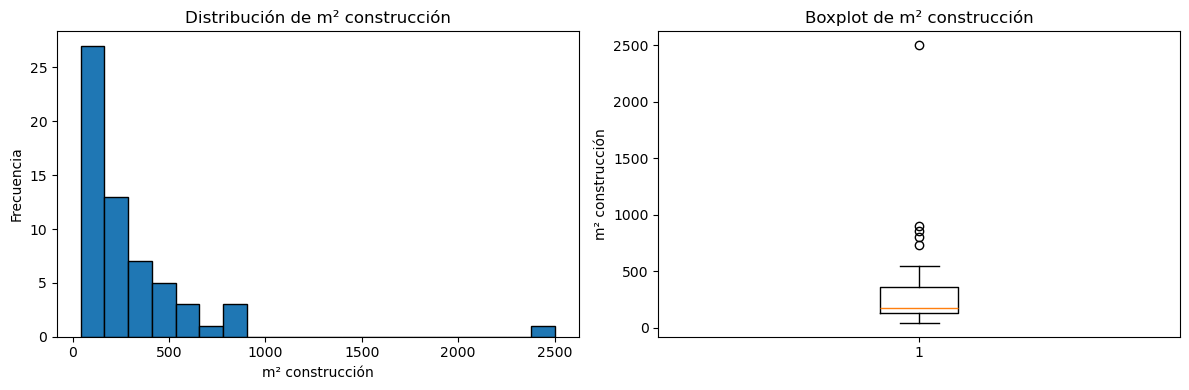

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['m2_construccion'], bins=20, edgecolor='black')
axes[0].set_title('Distribución de m² construcción')
axes[0].set_xlabel('m² construcción')
axes[0].set_ylabel('Frecuencia')

axes[1].boxplot(df['m2_construccion'])
axes[1].set_title('Boxplot de m² construcción')
axes[1].set_ylabel('m² construcción')

plt.tight_layout()
plt.show()

**Observación 6.3:** m2_construccion presenta sesgo positivo fuerte, 
similar al precio. La mayoría de propiedades tiene entre 50 y 300 m². 
Se detecta un outlier extremo en ~2,500 m² que se investigará en la 
Sección 10.

### 6.4 Superficie de terreno

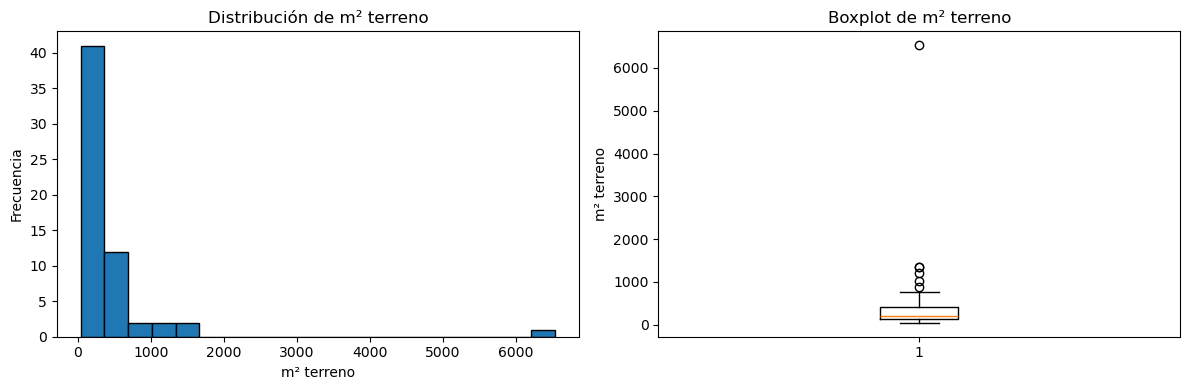

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['m2_terreno'], bins=20, edgecolor='black')
axes[0].set_title('Distribución de m² terreno')
axes[0].set_xlabel('m² terreno')
axes[0].set_ylabel('Frecuencia')

axes[1].boxplot(df['m2_terreno'])
axes[1].set_title('Boxplot de m² terreno')
axes[1].set_ylabel('m² terreno')

plt.tight_layout()
plt.show()

**Observación 6.4:** m2_terreno presenta el sesgo positivo más pronunciado 
del dataset. La gran mayoría de propiedades tiene menos de 500 m² de 
terreno. Se detecta un outlier extremo en ~6,500 m² completamente aislado 
del resto, y varios outliers entre 1,000–1,300 m². Se investigarán en la 
Sección 10.

### 6.5 Recámaras

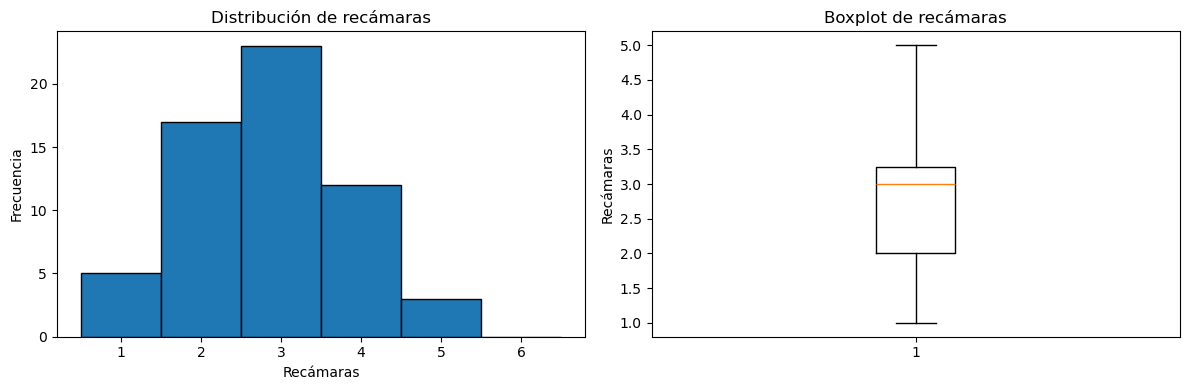

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['recamaras'], bins=range(1, 8), edgecolor='black', align='left')
axes[0].set_title('Distribución de recámaras')
axes[0].set_xlabel('Recámaras')
axes[0].set_ylabel('Frecuencia')
axes[0].set_xticks(range(1, 7))

axes[1].boxplot(df['recamaras'])
axes[1].set_title('Boxplot de recámaras')
axes[1].set_ylabel('Recámaras')

plt.tight_layout()
plt.show()

**Observación 6.5:** Recámaras presenta la distribución más simétrica del 
dataset, centrada en 3. Rango de 1 a 5 sin outliers. Es la variable 
numérica más estable y será un predictor confiable en el modelo.

### 6.6 Baños

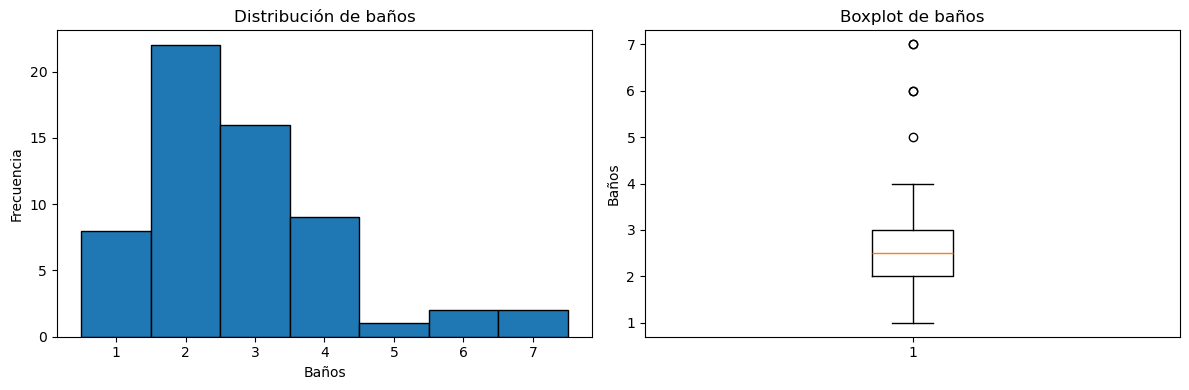

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['banos'], bins=range(1, 9), edgecolor='black', align='left')
axes[0].set_title('Distribución de baños')
axes[0].set_xlabel('Baños')
axes[0].set_ylabel('Frecuencia')
axes[0].set_xticks(range(1, 8))

axes[1].boxplot(df['banos'])
axes[1].set_title('Boxplot de baños')
axes[1].set_ylabel('Baños')

plt.tight_layout()
plt.show()

**Observación 6.6:** Baños muestra sesgo positivo moderado, centrado en 2. 
Se detectan 3 outliers en 5, 6 y 7 baños, probablemente propiedades de 
lujo. Recordar que medios baños no están capturados en esta columna sino 
en notas, por diseño del dataset.

### 6.7 Estacionamientos

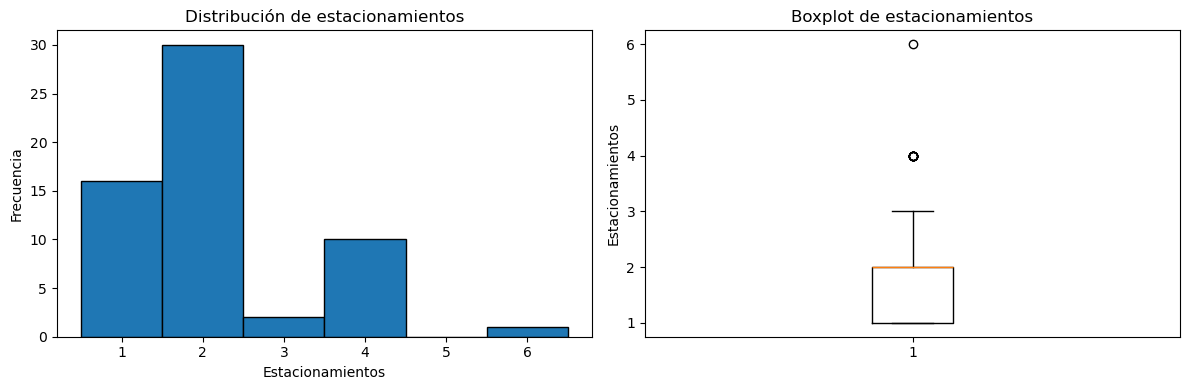

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['estacionamientos'].dropna(), bins=range(1, 8), edgecolor='black', align='left')
axes[0].set_title('Distribución de estacionamientos')
axes[0].set_xlabel('Estacionamientos')
axes[0].set_ylabel('Frecuencia')
axes[0].set_xticks(range(1, 7))

axes[1].boxplot(df['estacionamientos'].dropna())
axes[1].set_title('Boxplot de estacionamientos')
axes[1].set_ylabel('Estacionamientos')

plt.tight_layout()
plt.show()

**Observación 6.7:** Estacionamientos se concentra en 1 y 2, con un segundo 
pico inesperado en 4 que sugiere un segmento de propiedades grandes con 
garage amplio, posiblemente de colonias premium. Outliers en 4 y 6 
estacionamientos. Un registro con valor faltante excluido del análisis.

**Nota metodológica:** Se excluye `antigüedad` del análisis univariado por 
su alto porcentaje de valores faltantes (65%). Con solo 21 registros 
válidos, una distribución no sería estadísticamente representativa. Su uso 
en el modelo de la Fase 3 será limitado o nulo.

## 7. Variables categóricas
Distribución de tipo de inmueble, colonia y estatus de preventa.

### 7.1 Tipo de inmueble (casa vs departamento)

tipo_inmueble
casa            44
departamento    16
Name: count, dtype: int64


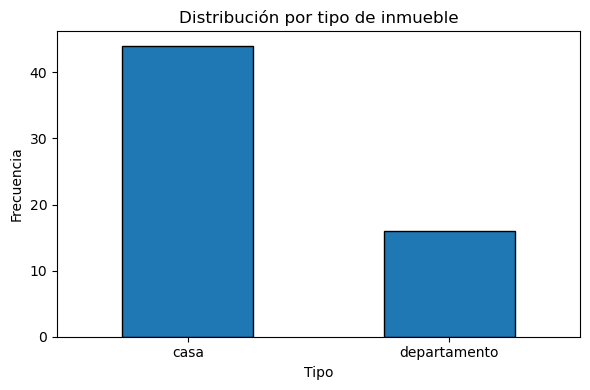

In [17]:
conteo = df['tipo_inmueble'].value_counts()
print(conteo)

fig, ax = plt.subplots(figsize=(6, 4))
conteo.plot(kind='bar', ax=ax, edgecolor='black')
ax.set_title('Distribución por tipo de inmueble')
ax.set_xlabel('Tipo')
ax.set_ylabel('Frecuencia')
ax.set_xticklabels(conteo.index, rotation=0)
plt.tight_layout()
plt.show()

**Observación 7.1:** El dataset está fuertemente desbalanceado: 73% casas 
vs 27% departamentos. Esto se documentará como limitación, ya que el 
modelo de la Fase 3 tendrá mayor precisión predictiva para casas. La 
distribución por colonia se analizará en la Sección 8.

### 7.2 Propiedades por colonia

colonia
yucatan country club    11
altabrisa               10
santa gertrudis copo    10
garcia gineres          10
chuburna de hidalgo     10
francisco de montejo     9
Name: count, dtype: int64


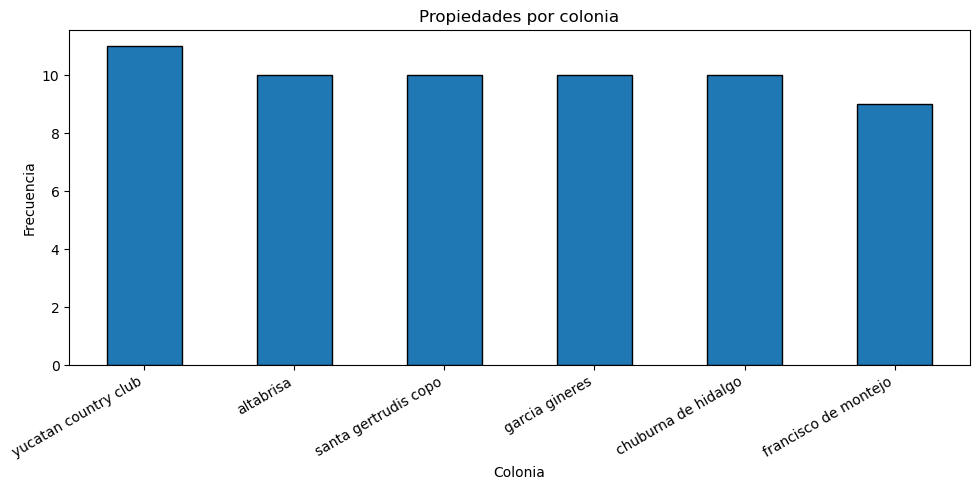

In [18]:
conteo_colonia = df['colonia'].value_counts()
print(conteo_colonia)

fig, ax = plt.subplots(figsize=(10, 5))
conteo_colonia.plot(kind='bar', ax=ax, edgecolor='black')
ax.set_title('Propiedades por colonia')
ax.set_xlabel('Colonia')
ax.set_ylabel('Frecuencia')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

**Observación 7.2:** Distribución balanceada por diseño: 10 propiedades 
por colonia, con ajustes documentados (Francisco de Montejo: 9, Yucatán 
Country Club: 11). El balance permite comparaciones directas entre 
colonias en la Sección 8.

### 7.3 Preventa vs no preventa

es_preventa
no    50
si    10
Name: count, dtype: int64


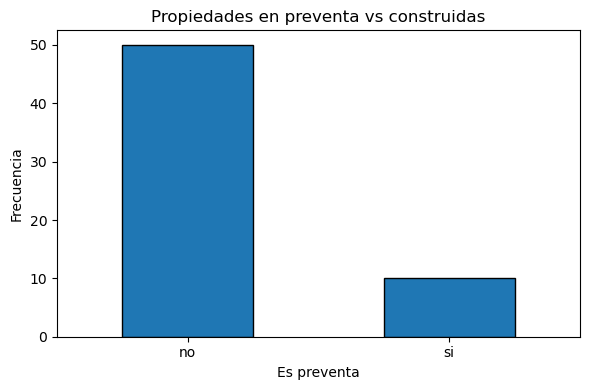

In [19]:
conteo_preventa = df['es_preventa'].value_counts()
print(conteo_preventa)

fig, ax = plt.subplots(figsize=(6, 4))
conteo_preventa.plot(kind='bar', ax=ax, edgecolor='black')
ax.set_title('Propiedades en preventa vs construidas')
ax.set_xlabel('Es preventa')
ax.set_ylabel('Frecuencia')
ax.set_xticklabels(conteo_preventa.index, rotation=0)
plt.tight_layout()
plt.show()

**Observación 7.3:** 17% de las propiedades están en preventa. La 
literatura de clases desbalanceadas considera proporciones >15% como 
manejables sin técnicas especiales de rebalanceo. En la Fase 3, antes 
de decidir el tratamiento de esta variable, se realizará una prueba 
estadística (e.g., test t de medias o Mann-Whitney) para evaluar si el 
precio difiere significativamente entre preventas y propiedades 
terminadas. Solo entonces se decidirá incluirla como predictor, 
filtrarla, o modelarlas por separado.

## 8. Análisis comparativo por colonia
Comparación de precio, precio por m² y superficie entre las 6 colonias del dataset.

### 8.1 Precio por colonia

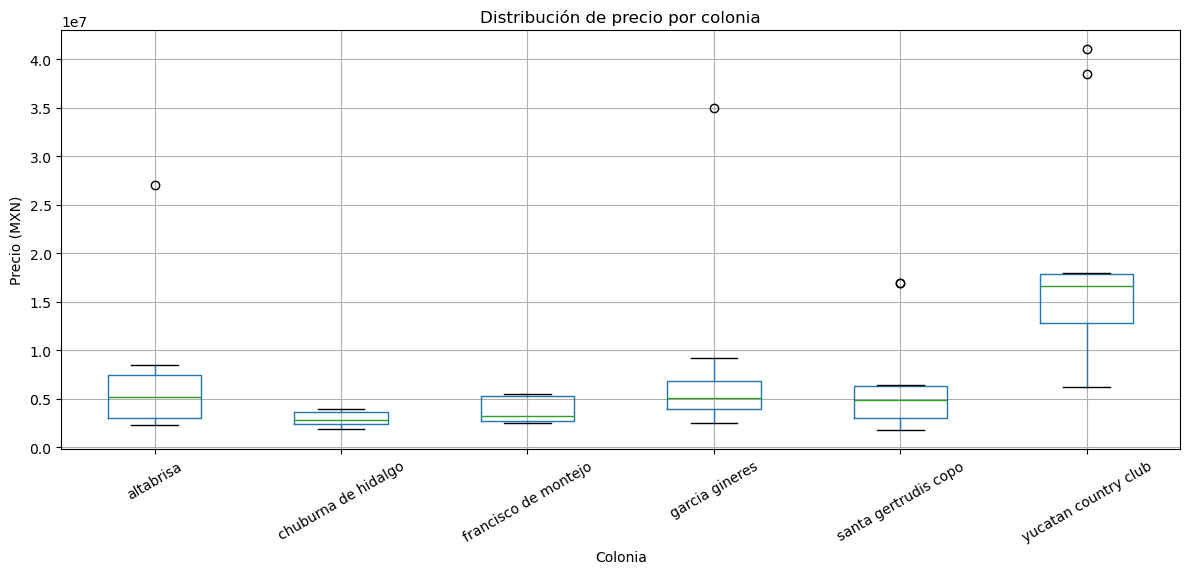

In [20]:
fig, ax = plt.subplots(figsize=(12, 6))
df.boxplot(column='precio', by='colonia', ax=ax, rot=30)
ax.set_title('Distribución de precio por colonia')
ax.set_xlabel('Colonia')
ax.set_ylabel('Precio (MXN)')
plt.suptitle('')
plt.tight_layout()
plt.show()

**Observación 8.1:** Se identifican tres segmentos de precio por colonia:
- **Premium**: Yucatán Country Club (mediana ~\$16.5M), en una categoría aparte.
- **Medio-alto**: Altabrisa, García Ginerés, Santa Gertrudis Copó (mediana ~\$5M).
- **Accesible**: Francisco de Montejo y Chuburná de Hidalgo (mediana ~\$3M).

Chuburná y Francisco de Montejo muestran cajas compactas (mercado homogéneo: 
propiedades con precios muy similares entre sí), mientras que YCC, Altabrisa 
y García Ginerés presentan alta variabilidad intra-colonia. Se detecta un 
outlier de ~\$35M en García Ginerés que se investigará en la Sección 10.

### 8.2 Precio por m² de construcción por colonia

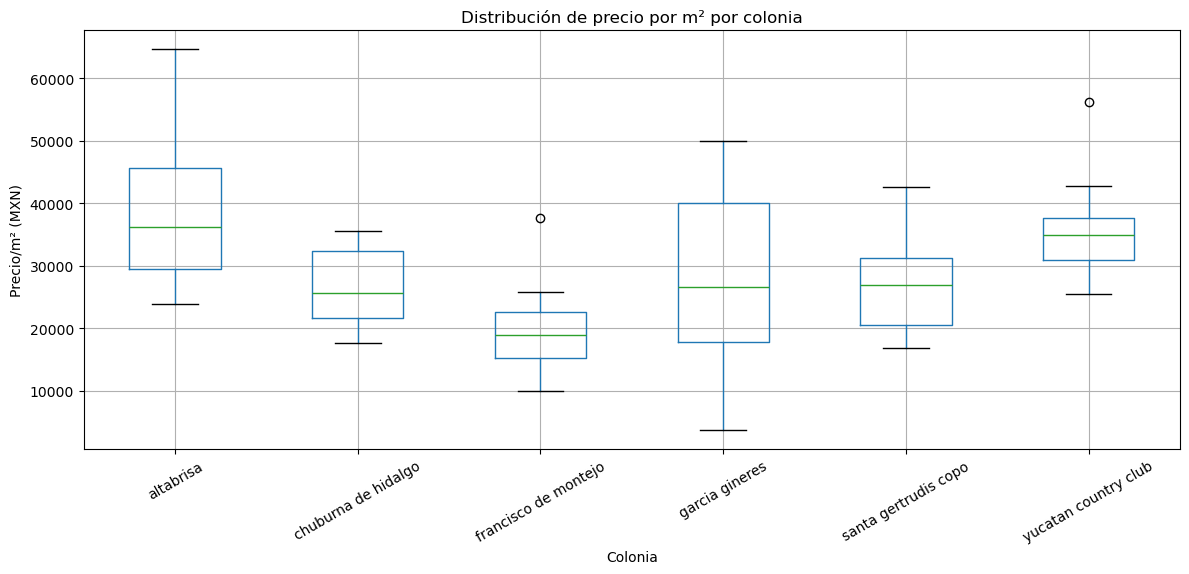

In [21]:
fig, ax = plt.subplots(figsize=(12, 6))
df.boxplot(column='precio_m2', by='colonia', ax=ax, rot=30)
ax.set_title('Distribución de precio por m² por colonia')
ax.set_xlabel('Colonia')
ax.set_ylabel('Precio/m² (MXN)')
plt.suptitle('')
plt.tight_layout()
plt.show()

**Observación 8.2:** Al normalizar por m² construcción, el ranking cambia 
significativamente respecto al precio absoluto:

- **Mayor valor por m²**: Altabrisa  (36,000 MXN) y Yucatán Country Club 
  (35,000 MXN), prácticamente empatados.
- **Segmento medio**: García Ginerés, Chuburná de Hidalgo, Santa Gertrudis 
  Copó (25,000–27,000 MXN).
- **Menor valor por m²**: Francisco de Montejo (19,000 MXN).

Dentro del grupo premium (YCC + Altabrisa), la diferencia en precio absoluto 
entre ambas se explica principalmente por tamaño, no por valor unitario. 
Esto no significa que YCC carezca de premium cualitativo —seguridad, club, 
estatus social son factores reales que ya están reflejados en su precio por 
m² ubicándolo en el grupo superior. Significa que YCC y Altabrisa compiten 
en un mismo nivel de valor unitario, pero YCC ofrece más superficie por 
propiedad.

**Limitación del dataset:** No se capturan variables cualitativas como 
seguridad, amenidades, prestigio o calidad de servicios. Estos factores 
quedan absorbidos en la variable `colonia`, que actúa como proxy compuesto 
de todos ellos. Esto explica por qué `colonia` será un predictor importante 
en el modelo: no por la ubicación geográfica per se, sino por las 
características no medidas que condensa.

### 8.3 Superficie de construcción por colonia

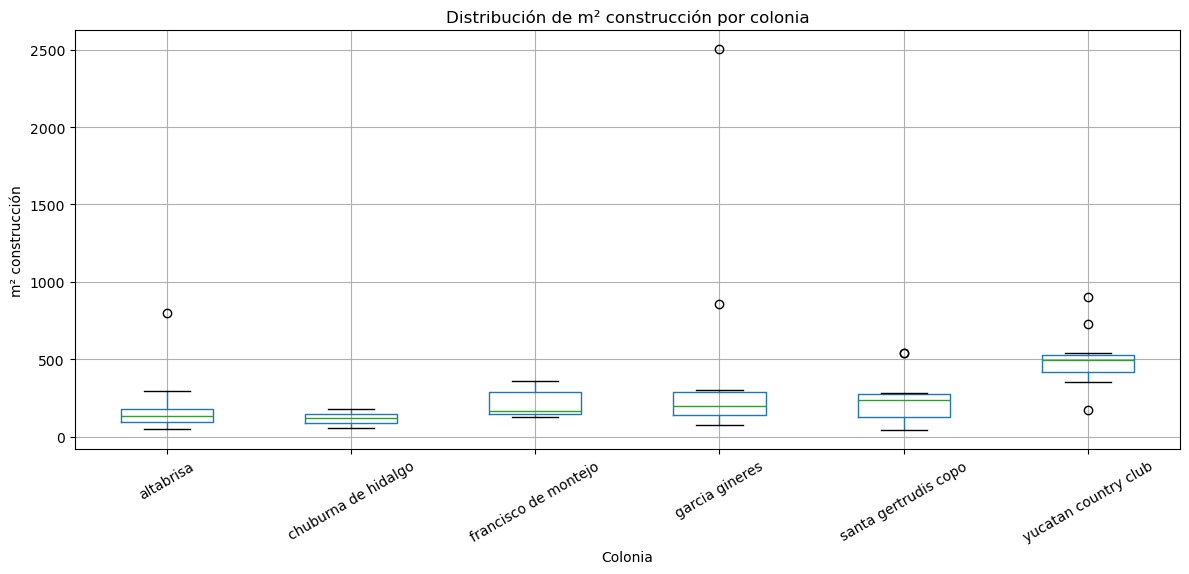

In [22]:
fig, ax = plt.subplots(figsize=(12, 6))
df.boxplot(column='m2_construccion', by='colonia', ax=ax, rot=30)
ax.set_title('Distribución de m² construcción por colonia')
ax.set_xlabel('Colonia')
ax.set_ylabel('m² construcción')
plt.suptitle('')
plt.tight_layout()
plt.show()

**Observación 8.3:** YCC presenta propiedades sustancialmente más grandes 
que el resto (mediana ~480 m² vs 120-230 m² en las demás colonias), 
confirmando que el premium absoluto de YCC viene en parte del mayor tamaño 
promedio. Chuburná tiene las propiedades más compactas.

Outliers destacados:
- García Ginerés: propiedad de ~2,500 m² completamente atípica para esa colonia.
- YCC: outlier inferior de ~170 m² (probablemente un departamento).
- Altabrisa, Santa Gertrudis Copó: outliers superiores significativos.

Existe correlación entre `colonia` y `m2_construccion`: el modelo deberá 
considerar esta interacción.

## 9. Correlaciones
Relación entre las variables numéricas del dataset.

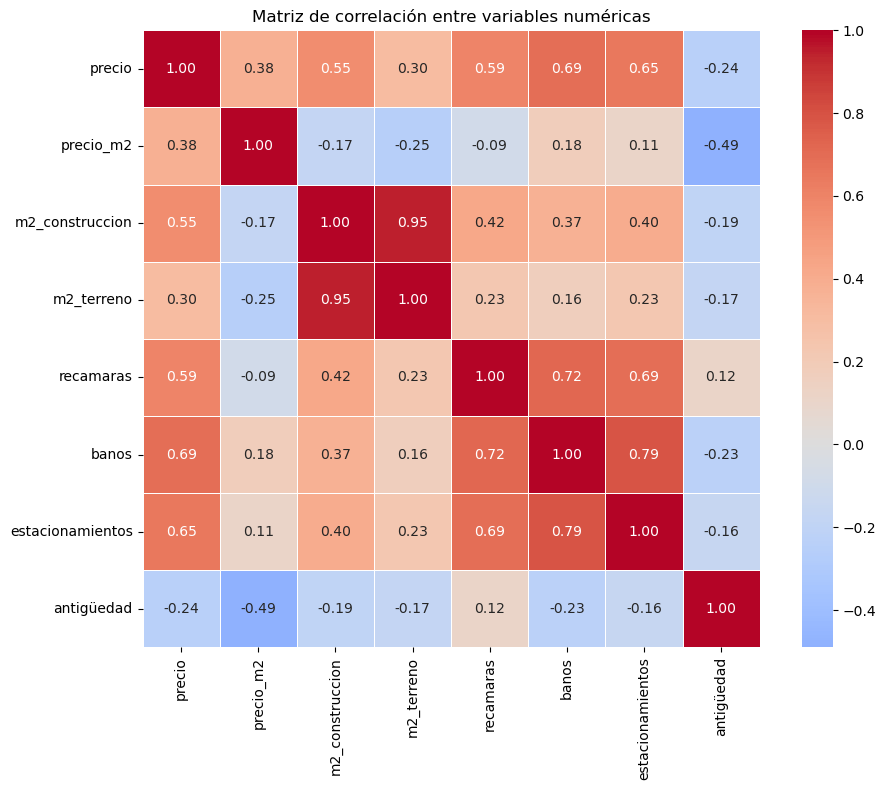

In [24]:
variables_numericas = ['precio', 'precio_m2', 'm2_construccion', 'm2_terreno', 
                       'recamaras', 'banos', 'estacionamientos', 'antigüedad']
corr = df[variables_numericas].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', 
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Matriz de correlación entre variables numéricas')
plt.tight_layout()
plt.show()

**Observación 9:** Hallazgos clave de la matriz de correlación:

**Variables más correlacionadas con precio:**
- `banos` (0.69), `estacionamientos` (0.65), `recamaras` (0.59) superan a `m2_construccion` (0.55).
- Esto sugiere que estas variables capturan el "nivel de lujo" mejor que el tamaño puro.

**Multicolinealidad — implicación crítica para el modelo:**
- `m2_construccion` ↔ `m2_terreno`: 0.95 — extremadamente alta. NO se deben incluir 
  ambas variables simultáneamente en un modelo de regresión. Se elegirá una o se 
  creará una variable derivada (ej: razón terreno/construcción).
- Cluster banos-recamaras-estacionamientos: correlaciones entre 0.69 y 0.79. 
  Requerirá tratamiento (selección de variables o reducción de dimensionalidad).

**Sobre antigüedad:**
- Correlación más fuerte con `precio_m2` (-0.49) que con precio absoluto (-0.24).
- Con solo 21 registros válidos, estas correlaciones son menos confiables y 
  pueden cambiar significativamente con más datos.

**Sobre precio_m2:**
- Correlación moderada con `precio` (0.38), confirmando que captura información 
  distinta y no es redundante con precio absoluto.

## 10. Detección de outliers
Identificación de propiedades con valores atípicos en precio y superficie.

In [25]:
def detectar_outliers_iqr(serie):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    return (serie < limite_inferior) | (serie > limite_superior)

outliers_precio = detectar_outliers_iqr(df['precio'])
outliers_m2_const = detectar_outliers_iqr(df['m2_construccion'])
outliers_m2_terr = detectar_outliers_iqr(df['m2_terreno'])

df['es_outlier'] = outliers_precio | outliers_m2_const | outliers_m2_terr

print(f"Total de outliers detectados: {df['es_outlier'].sum()}")
print(f"Porcentaje: {(df['es_outlier'].sum() / len(df) * 100):.1f}%\n")

df[df['es_outlier']][['colonia', 'tipo_inmueble', 'precio', 'm2_construccion', 
                      'm2_terreno', 'recamaras', 'banos', 'es_preventa', 'notas']]

Total de outliers detectados: 9
Porcentaje: 15.0%



,colonia,tipo_inmueble,precio,m2_construccion,m2_terreno,recamaras,banos,es_preventa,notas
4,altabrisa,casa,27000000,800,890,4,4,no,"Casa en condominio, piscina con baño completo,..."
15,santa gertrudis copo,casa,16900000,542,1346,3,4,no,"alberca con jacuzzi, bar, cuarto de servicio, ..."
18,santa gertrudis copo,casa,16900000,542,1346,3,4,no,"alberca con jacuzzi, bar, cuarto de servicio c..."
21,garcia gineres,casa,9250000,2502,6531,3,2,no,"alberca tipo cacahuate, una planta, portón aut..."
29,garcia gineres,casa,35000000,859,1029,5,3,no,"alberca, cuarto de servicio con acceso indepen..."
51,yucatan country club,casa,17800000,493,531,4,6,no,"piscina con cascada (6x2.8m), cuarto de servic..."
54,yucatan country club,casa,17950000,540,630,5,7,no,"piscina con baño exterior, bar en terraza, cua..."
55,yucatan country club,casa,38500000,900,1208,4,7,no,"piscina (8x3.5m), bodega, despacho con baño co..."
56,yucatan country club,casa,41000000,730,752,4,4,no,"frente al campo de golf, family room, estudio ..."


**Verificación:** Las filas 15 y 18 aparecen con valores idénticos en los outliers. 
Revisamos sus notas para confirmar si están marcadas como duplicados según la 
metodología de Fase 1.

In [27]:
pd.set_option('display.max_colwidth', None)
df.loc[[15, 18], ['colonia', 'precio', 'notas']]

,colonia,precio,notas
15,santa gertrudis copo,16900000,"alberca con jacuzzi, bar, cuarto de servicio, bodega, una planta, 4.5 baños"
18,santa gertrudis copo,16900000,"alberca con jacuzzi, bar, cuarto de servicio con cocina, bodega, una planta, 4.5 baños, posible duplicado casa 16"


**Observación 10:** Se detectan 9 outliers (15% del dataset), distribuidos así:

- **Yucatán Country Club: 4 outliers** (rows 51, 54, 55, 56) — propiedades premium genuinas con piscina y amenidades.
- **García Ginerés: 2 outliers** — row 21 (2,502 m² construcción, 6,531 m² terreno, solo 3 recámaras — probablemente propiedad colonial con jardín extenso) y row 29 ($35M, casa de lujo en colonia tradicional).
- **Santa Gertrudis Copó: 2 outliers** (rows 15 y 18) — confirmados como posible duplicado según metodología de Fase 1.
- **Altabrisa: 1 outlier** (row 4) — casa en condominio de lujo.

**Patrones:**
- Todos los outliers son casas (ninguno es departamento).
- Ninguno es preventa.
- La mayoría incluye piscina.

**Implicaciones para Fase 3:**
- 15% es demasiado para eliminarlos directamente; representan segmentos reales del mercado.
- Estrategias recomendadas: transformación logarítmica del precio, modelos robustos a outliers (Random Forest, Gradient Boosting), o modelado estratificado por segmento.
- Excluir filas marcadas como "posible duplicado" del conjunto de entrenamiento.

## 11. Análisis del campo notas
Identificación de features candidatas a convertir en variables binarias 
para el modelo de valuación: piscina, lock-off, mantenimiento, esquina, etc.

In [33]:
keywords = {
    'piscina': ['piscina', 'alberca'],
    'cuarto_servicio': ['cuarto de servicio'],
    'una_planta': ['una planta'],
    'lock_off': ['lock-off', 'lock off'],
    'esquina': ['esquina'],
    'a_estrenar': ['a estrenar'],
    'paneles_solares': ['paneles solares'],
    'sin_mantenimiento': ['sin cuota de mantenimiento', 'sin mantenimiento'],
    'mantenimiento_con_monto': ['mantenimiento $'],
    'townhouse': ['townhouse'],
    'condominio': ['condominio', 'en condominio'],
    'frente_parque': ['frente a parque', 'frente al parque'],
    'uso_mixto': ['uso mixto'],
    'posible_duplicado': ['posible duplicado'],
}

notas_lower = df['notas'].fillna('').str.lower()
conteo = {}
for feature, terms in keywords.items():
    conteo[feature] = notas_lower.apply(
        lambda x: any(term in x for term in terms)
    ).sum()

resumen = pd.DataFrame({
    'feature': list(conteo.keys()),
    'frecuencia': list(conteo.values()),
    'porcentaje': [round(c / len(df) * 100, 1) for c in conteo.values()]
}).sort_values('frecuencia', ascending=False).reset_index(drop=True)

resumen

,feature,frecuencia,porcentaje
0,piscina,38,63.3
1,cuarto_servicio,15,25.0
2,una_planta,10,16.7
3,mantenimiento_con_monto,8,13.3
4,a_estrenar,6,10.0
5,paneles_solares,5,8.3
6,townhouse,5,8.3
7,condominio,4,6.7
8,esquina,3,5.0
9,lock_off,2,3.3


**Observación 11:** El análisis del campo `notas` revela varias features 
candidatas a extraer como variables binarias en la Fase 3:

**Candidatos viables (frecuencia >10%):**
- `piscina` (63%): feature más impactante, probablemente correlacionada con precio.
- `cuarto_servicio` (25%): indicador de propiedades de mayor lujo.
- `una_planta` (17%): atributo arquitectónico relevante en clima cálido.
- `mantenimiento_con_monto` (13%): probable indicador de condominios horizontales 
  y verticales. Su correlación con `tipo_inmueble` (departamento) y colonias 
  específicas se verificará en Fase 3.

**Candidatos borderline (5–10%):** a_estrenar, paneles_solares, townhouse, 
condominio, esquina. Con 60 propiedades, una variable binaria necesita al 
menos 10-15 ejemplos para tener potencia estadística. La mayoría de estos 
quedarán fuera del modelo inicial.

**Insuficientes (<5%):** lock_off, sin_mantenimiento, uso_mixto, 
frente_parque, posible_duplicado. Descriptivamente útiles, no modelables.

**Detalle metodológico:** La detección inicial de `mantenimiento_con_monto` 
falló porque el keyword original (`mantenimiento mensual`) no coincidía con 
el formato real en las notas (`mantenimiento $X/mes`). Tras ajustar la 
regla a `mantenimiento $`, se identificaron 8 propiedades correctamente. 
Este tipo de iteración será necesaria al construir features de texto en 
Fase 3.

**Próximo paso (Fase 3):** Crear columnas binarias para piscina, 
cuarto_servicio, una_planta y mantenimiento_con_monto. Evaluar correlación 
con precio antes de decidir incluir las features borderline.

## 12. Conclusiones y próximos pasos

### 12.1 Hallazgos principales

**Calidad de datos:**
- Las variables clave para el modelo (precio, m2_construccion, m2_terreno, 
  recamaras, banos) están completas al 100%.
- `antigüedad` tiene 65% de valores faltantes y tendrá uso limitado.

**Distribuciones:**
- `precio`, `m2_construccion` y `m2_terreno` presentan sesgo positivo marcado. 
  Se requerirá transformación logarítmica del precio para el modelo.
- `recamaras` es la variable más estable, centrada en 3.
- `precio_m2` es más simétrica que el precio absoluto y resulta más estable 
  para comparaciones entre propiedades.

**Variables categóricas:**
- Dataset desbalanceado: 73% casas vs 27% departamentos.
- 17% de propiedades están en preventa; su tratamiento se decidirá con prueba 
  estadística en Fase 3.

**Análisis por colonia — hallazgo clave:**
- Tres segmentos de precio absoluto: premium (YCC), medio (Altabrisa, García 
  Ginerés, Santa Gertrudis Copó) y accesible (Chuburná, Francisco de Montejo).
- Al normalizar por m², YCC y Altabrisa quedan empatadas: el premium absoluto 
  de YCC se debe principalmente al tamaño de sus propiedades, no al valor 
  unitario por m².
- La variable `colonia` actúa como proxy compuesto de factores cualitativos 
  no medidos (seguridad, amenidades, prestigio).

**Correlaciones — implicación crítica:**
- Multicolinealidad severa entre `m2_construccion` y `m2_terreno` (r=0.95). 
  No se pueden incluir ambas en una regresión lineal.
- Cluster correlacionado: `banos`, `recamaras`, `estacionamientos` (r=0.69–0.79).
- `banos` y `estacionamientos` superan a `m2_construccion` en correlación 
  con precio, sugiriendo que capturan mejor el "nivel de lujo".

**Outliers:**
- 15% del dataset (9 propiedades), concentrados en YCC y García Ginerés.
- Representan segmentos reales del mercado (lujo, propiedades coloniales grandes), 
  no errores de captura.
- Filas 15 y 18 confirmadas como duplicados según metodología de Fase 1.

**Features candidatas del campo notas:**
- Viables: `piscina` (63%), `cuarto_servicio` (25%), `una_planta` (17%), 
  `mantenimiento_con_monto` (13%).
- Borderline o insuficientes: el resto se documentará pero no entrará al modelo.

---

### 12.2 Limitaciones del dataset

1. **Tamaño de muestra reducido** (n=60). Limita la potencia estadística y 
   restringe la complejidad del modelo a entrenar.
2. **Desbalance casa/departamento** (73/27). El modelo tendrá mayor capacidad 
   predictiva para casas.
3. **`antigüedad` con 65% de faltantes**. Tendrá uso limitado o nulo.
4. **Variables cualitativas no capturadas**: seguridad, amenidades, prestigio, 
   calidad de servicios. Quedan absorbidas en la variable `colonia`.
5. **15% de outliers** representando segmentos reales del mercado, no errores.

---

### 12.3 Decisiones para Fase 3 (Modelado)

**Preprocesamiento:**
- Aplicar `log(precio)` como variable objetivo.
- Excluir filas marcadas como "posible duplicado" del conjunto de entrenamiento.
- Crear variables binarias: `tiene_piscina`, `tiene_cuarto_servicio`, 
  `es_una_planta`, `tiene_mantenimiento_con_monto`.
- Refinar regla de extracción para features de texto borderline si se incluyen.

**Selección de variables:**
- Elegir entre `m2_construccion` y `m2_terreno`, o crear variable derivada 
  (ej: `ratio_terreno_construccion`).
- Evaluar tratamiento del cluster `banos-recamaras-estacionamientos`: 
  selección por importancia o reducción de dimensionalidad.

**Prueba previa al modelado:**
- Test t o Mann-Whitney para evaluar si el precio difiere significativamente 
  entre preventas y propiedades terminadas. Solo entonces decidir inclusión, 
  filtrado o modelado separado.

**Modelo:**
- **Baseline:** regresión lineal con `log(precio)` como objetivo, usando 
  variables seleccionadas y libres de multicolinealidad.
- **Comparación:** Random Forest y Gradient Boosting, robustos a outliers 
  y multicolinealidad, no requieren transformación logarítmica.
- **Evaluación:** RMSE y MAE en escala original (revirtiendo log), validación 
  cruzada k-fold con k=5.

---

<!--
### 12.4 Próximos pasos inmediatos

1. Cerrar Fase 2 con commit del notebook completo al repositorio.
2. Actualizar README con limitaciones identificadas en el EDA.
3. Iniciar Fase 3: feature engineering y construcción del modelo baseline.
-->
